In [1]:
import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import numpy as np

from functools import partial
import matplotlib.pyplot as plt

import blackjax

# Set device to CPU 
jax.config.update("jax_platform_name", "cpu")


In [2]:
from probjax.inference.univariate import ars, sample_upper, eval_lower, eval_upper, init_ars_state, update_ars_state

In [25]:
def log_potential(x):
    return  jnp.log(jnp.exp(-0.5 * (x - 2) ** 2) + jnp.exp(-0.5 * (x + 2) ** 2) + jnp.exp(-10. * (x - 5) ** 2))

In [42]:
state = init_ars_state(log_potential, jnp.linspace(-8, 9, 5), max_points=100)

In [43]:
state.s

Array([ 0.0000000e+00,  8.7458134e-04, -2.1113257e-03,  8.3694817e+01,
        6.6644547e+01,  6.7470795e+01,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
      

In [44]:
samples2, indices = jax.vmap(lambda k: sample_upper(state, k))(jax.random.split(jax.random.PRNGKey(0), 100000))
logpdf = jax.vmap(lambda x, i: eval_upper(state, x, i))(samples2, indices)
logpdf_lower = jax.vmap(lambda x: eval_lower(state, x))(samples2)


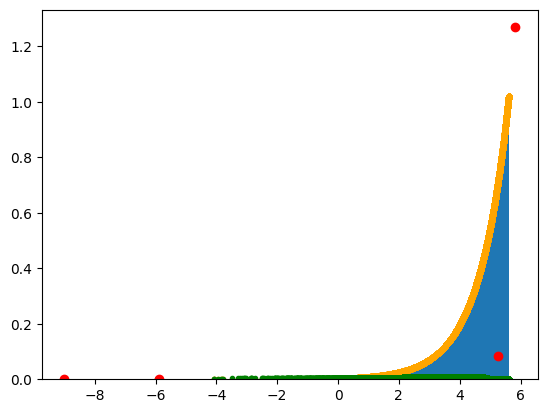

In [45]:

_ = plt.hist(samples2, bins=100, density=True)
_ = plt.scatter(samples2, jnp.exp(logpdf)/state.s[state.num_points], color='orange', marker=".")
_ = plt.scatter(samples2, jnp.exp(logpdf_lower)/state.s[state.num_points], color='green', marker=".")
_ = plt.scatter(state.z, jnp.exp(state.u)/state.s[state.num_points], color="red")

In [46]:
samples, state, acceptance_prob = ars(state, jax.random.PRNGKey(0), 100000, log_potential)

In [47]:
acceptance_prob

Array(0.99504465, dtype=float32, weak_type=True)

(array([7.85323712e-05, 7.85323712e-05, 2.35597114e-04, 1.57064742e-04,
        3.14130661e-04, 7.06791341e-04, 2.35597114e-04, 1.57064742e-03,
        2.19890639e-03, 1.80624454e-03, 3.61248907e-03, 6.04699258e-03,
        6.91084866e-03, 1.11515967e-02, 1.43714239e-02, 1.74342517e-02,
        2.30884739e-02, 2.60727961e-02, 3.91876532e-02, 4.67267609e-02,
        5.48941275e-02, 6.39253501e-02, 8.00246361e-02, 9.28252627e-02,
        1.06018701e-01, 1.16463506e-01, 1.34290355e-01, 1.46698744e-01,
        1.61619620e-01, 1.65546238e-01, 1.72535620e-01, 1.79132339e-01,
        1.73713768e-01, 1.84943907e-01, 1.66253030e-01, 1.66095965e-01,
        1.56043968e-01, 1.49290038e-01, 1.35311402e-01, 1.16777636e-01,
        1.03191584e-01, 9.96576257e-02, 8.12810042e-02, 7.57052413e-02,
        6.66740144e-02, 5.50512180e-02, 5.20669743e-02, 5.07319355e-02,
        5.24596424e-02, 5.20669804e-02, 5.41088291e-02, 6.16479258e-02,
        6.81661141e-02, 7.93177320e-02, 8.99981395e-02, 9.824404

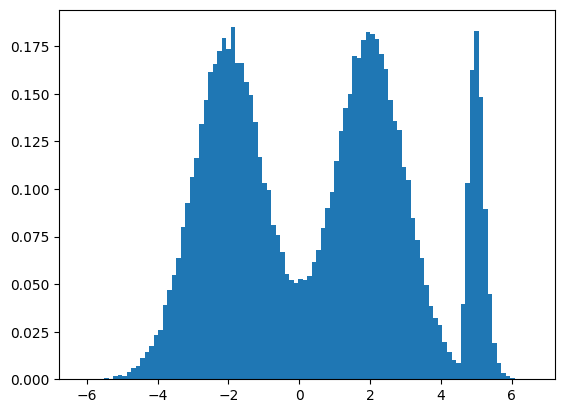

In [49]:
plt.hist(samples, bins=100, density=True)

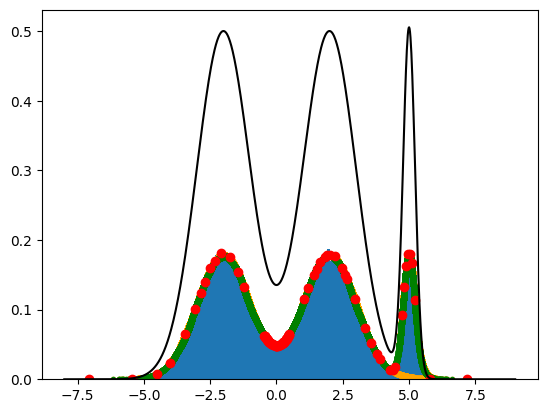

In [48]:
samples2, indices = jax.vmap(lambda k: sample_upper(state, k))(jax.random.split(jax.random.PRNGKey(0), 100000))
logpdf = jax.vmap(lambda x, i: eval_upper(state, x, i))(samples2, indices)
logpdf_lower = jax.vmap(lambda x: eval_lower(state, x))(samples2)

_ = plt.hist(samples2, bins=100, density=True)
_ = plt.scatter(samples2, jnp.exp(logpdf)/state.s[state.num_points], color='orange', marker=".")
_ = plt.scatter(samples2, jnp.exp(logpdf_lower)/state.s[state.num_points], color='green', marker=".")
_ = plt.scatter(state.z, jnp.exp(state.u)/state.s[state.num_points], color="red")
_ = plt.plot(jnp.linspace(-8, 9, 1000), jnp.exp(log_potential(jnp.linspace(-8, 9, 1000)))/2, color="black")

In [29]:


import numpy as np
import random
from matplotlib import pyplot as plt
import warnings

class ARS():
    '''
    This class implements the Adaptive Rejection Sampling technique of Gilks and Wild '92.
    Where possible, naming convention has been borrowed from this paper.
    The p.d.f. must be log-concave.

    Currently does not exploit lower hull described in paper- which is fine for drawing
    only small amount of samples at a time.
    '''
    
    def __init__(self, f, fprima, xi=[-4,1,4], lb=-np.Inf, ub=np.Inf, use_lower=False, ns=50, **fargs):
        '''
        initialize the upper (and if needed lower) hulls with the specified params
        
        Parameters
        ==========
        f: function that computes log(f(u,...)), for given u, where f(u) is proportional to the
           density we want to sample from
        fprima:  d/du log(f(u,...))
        xi: ordered vector of starting points in wich log(f(u,...) is defined
            to initialize the hulls
        D: domain limits
        use_lower: True means the lower sqeezing will be used; which is more efficient
                   for drawing large numbers of samples
        
        
        lb: lower bound of the domain
        ub: upper bound of the domain
        ns: maximum number of points defining the hulls
        fargs: arguments for f and fprima
        '''
        
        self.lb = lb
        self.ub = ub
        self.f = f
        self.fprima = fprima
        self.fargs = fargs
        
        #set limit on how many points to maintain on hull
        self.ns = 50
        self.x = np.array(xi) # initialize x, the vector of absicassae at which the function h has been evaluated
        self.h = self.f(self.x, **self.fargs)
        self.hprime = self.fprima(self.x, **self.fargs)

        #Avoid under/overflow errors. the envelope and pdf are only
        # proporitional to the true pdf, so can choose any constant of proportionality.
        self.offset = 0.# np.amax(self.h)
        self.h = self.h-self.offset 

        ## check log-concavity, but not necessary
        # Derivative at first point in xi should potentially be > 0
        # Derivative at last point in xi should potentially be < 0
        if not(self.hprime[0] > 0): 
            warnings.warn("first point: initial anchor points must span mode of PDF")
        if not(self.hprime[-1] < 0):
            ## use this raise at risk,
            ## note that in Beta(1.5, 1), this condition does not need to meet
            warnings.warn("last point: initial anchor points must span mode of PDF")
        self.insert() 

        
    def draw(self, N):
        '''
        Draw N samples and update upper and lower hulls accordingly
        '''

        '''
        hl: lower hull
        hu: upper hull
        '''
        samples = np.zeros(N)
        n=0
        while n < N:
            [xt,i] = self.sampleUpper()

            hl = self.f(xt, **self.fargs)
            hprimet = self.fprima(xt, **self.fargs)
            hl = hl - self.offset
            #hu = np.amin(self.hprime*(xt-x) + self.h);
            hu = self.h[i] + (xt-self.x[i])*self.hprime[i]

            ## Accept sample? - Currently don't use lower
            u = random.random()  ## Sample u from a uniform distribution over (0, 1)
            if u < np.exp(hl-hu):
                ## accept sample
                samples[n] = xt
                n +=1
            else:
                hx = self.f(xt, **self.fargs)
                if u < np.exp(hx-hu):
                    ## accept sample
                    samples[n] = xt
                    n +=1
                else:
                    ## reject sample
                    pass

            # Update hull with new function evaluations
            if self.u.__len__() < self.ns:
                self.insert([xt],[hl],[hprimet])
            
        return samples

    
    def insert(self,xnew=[],hnew=[],hprimenew=[]):
        '''
        Update hulls with new point(s) if none given, just recalculate hull from existing x,h,hprime
        '''
        if xnew.__len__() > 0:
            x = np.hstack([self.x,xnew])
            idx = np.argsort(x)
            self.x = x[idx]
            self.h = np.hstack([self.h, hnew])[idx]
            self.hprime = np.hstack([self.hprime, hprimenew])[idx]

        self.z = np.zeros(self.x.__len__()+1)
        
        # This is the formula explicitly stated in Gilks. 
        # Requires 7(N-1) computations 
        # Following line requires 6(N-1)
        # self.z[1:-1] = (np.diff(self.h) + self.x[:-1]*self.hprime[:-1] - self.x[1:]*self.hprime[1:]) / -np.diff(self.hprime); 

        self.z[1:-1] = (np.diff(self.h) - np.diff(self.x*self.hprime))/-np.diff(self.hprime) 
        
        self.z[0] = self.lb; self.z[-1] = self.ub
        N = self.h.__len__()
        bins = list(range(N))
        self.u = self.hprime[[0]+bins]*(self.z-self.x[[0]+bins]) + self.h[[0]+bins]

        self.s = np.hstack([0,np.cumsum(np.diff(np.exp(self.u))/self.hprime)])
        self.cu = self.s[-1]


    def sampleUpper(self):
        '''
        Return a single value randomly sampled from the upper hull and index of segment
        '''
        u = random.random()
        
        # Find the largest z such that sc(z) < u
        i = np.nonzero(self.s/self.cu < u)[0][-1] 

        # Figure out x from inverse cdf in relevant sector
        xt = self.x[i] + (-self.h[i] + np.log(self.hprime[i]*(self.cu*u - self.s[i]) + 
        np.exp(self.u[i]))) / self.hprime[i]

        return [xt,i]


In [30]:
from sympy import symbols, integrate, exp

x = symbols('x')
a = symbols('a')
b = symbols('b')
l = symbols("l")
u = symbols("u")

f = exp(a*x + b)

integral_f = integrate(f, (x, l,u))
integral_f

Piecewise((-exp(a*l + b)/a + exp(a*u + b)/a, (a > -oo) & (a < oo) & Ne(a, 0)), (-l + u, True))

In [31]:
def f(x):
    """
    Log beta distribution
    """
    return -x**2


def fprima(x, a=1.5, b=1):
    """
    Derivative of Log beta distribution
    """
    return -2*x


# x = np.linspace(-100,100,100)

ars = ARS(f, fprima, xi=[-2,0,2.], ns=100)

/tmp/ipykernel_12072/3487047299.py:135: RuntimeWarning: invalid value encountered in divide
  self.s = np.hstack([0,np.cumsum(np.diff(np.exp(self.u))/self.hprime)])


In [32]:
xs = jax.random.normal(jax.random.PRNGKey(0), (3,))
xs = jnp.sort(xs)
h = f(xs)
hprime = fprima(xs)

z = (np.diff(h) + xs[:-1]*hprime[:-1] - xs[1:]*hprime[1:]) / -np.diff(hprime)
z = jnp.concatenate([jnp.array([-np.inf]), z, jnp.array([np.inf])])

In [33]:
u = jnp.empty_like(z)
u = u.at[0].set(hprime[0]*(z[0]-xs[0])+ h[0])
u = u.at[1:].set(hprime*(z[1:]-xs) + h)

s = jnp.zeros_like(u)
s = s.at[1:].set(np.cumsum(np.diff(np.exp(u))/hprime))

In [34]:

from typing import NamedTuple
from jaxtyping import Array, PyTree

import jax
import jax.numpy as jnp

class ARSState(NamedTuple):
    xs : Array
    h: Array 
    hprime: Array
    z: Array
    u: Array
    s: Array
    current_support_points: int

def init_ars_state(f, fprima, xi, max_points=50):
    num_initial_points = len(xi)
    
    # x = jnp.empty((max_points,))
    # h = jnp.empty((max_points,))
    # hprime = jnp.empty((max_points,))
    # z = jnp.empty((max_points+1,))
    
    x = jnp.sort(xi)
    h = f(x)
    hprime = fprima(x) 
    z = (jnp.diff(h) + x[:-1]*hprime[:-1] - x[1:]*hprime[1:]) / -jnp.diff(hprime)
    z = jnp.concatenate([jnp.array([-jnp.inf]), z, jnp.array([jnp.inf])])

    u = jnp.empty_like(z)
    u = u.at[0].set(hprime[0]*(z[0]-x[0])+ h[0])
    u = u.at[1:].set(hprime*(z[1:]-x) + h)
    

    s = jnp.zeros_like(u)
    s_sub = jnp.where(jnp.abs(hprime) > 1e-5, jnp.diff(jnp.exp(u))/hprime, z[1:] - z[:-1])
    s = s.at[1:].set(jnp.cumsum(s_sub))
    
    x = jnp.concatenate([x, jnp.full(max_points - num_initial_points, jnp.inf)])
    h = jnp.concatenate([h, jnp.full(max_points - num_initial_points, jnp.inf)])
    hprime = jnp.concatenate([hprime, jnp.full(max_points - num_initial_points, jnp.inf)])
    
    z = jnp.concatenate([z, jnp.full(max_points - num_initial_points, jnp.inf)])
    u = jnp.concatenate([u, jnp.full(max_points - num_initial_points, jnp.inf)])
    s = jnp.concatenate([s, jnp.full(max_points - num_initial_points, jnp.inf)])
    
    return ARSState(x, h, hprime, z, u, s, num_initial_points)

def dyn_slice(arr, i):
    return jax.lax.dynamic_slice(arr, (i,), (1,))

def update_ars_state(state: ARSState, x, h, hprime):
    new_index = state.current_support_points
    
    def update(state, x, h, hprime):
        xs = state.xs.at[new_index].set(x)
        h = state.h.at[new_index].set(h)
        hprime = state.hprime.at[new_index].set(hprime)
        idx = jnp.argsort(xs)
        xs = xs[idx]
        h = h[idx]
        hprime = hprime[idx]
        z = (jnp.diff(h) + xs[:-1]*hprime[:-1] - xs[1:]*hprime[1:]) / -jnp.diff(hprime)
        z = jnp.concatenate([jnp.array([-jnp.inf]),z, jnp.array([jnp.inf])])
        z = z.at[new_index+1].set(jnp.inf)
        
        u = jnp.empty_like(z)
        u = u.at[0].set(hprime[0]*(z[0]-xs[0])+ h[0])
        u = u.at[1:].set(hprime*(z[1:]-xs) + h)
        
        s = jnp.zeros_like(u)
        s_sub = jnp.where(jnp.abs(hprime) > 1e-5, jnp.diff(jnp.exp(u))/hprime, z[1:] - z[:-1])
        
        s = s.at[1:].set(jnp.cumsum(s_sub))
        return ARSState(xs, h, hprime, z, u, s, state.current_support_points+1)
    
    def do_nothing(state, x, h, hprime):
        return ARSState(state.xs, state.h, state.hprime, state.z, state.u, state.s, state.current_support_points)
    
    max_points = len(state.xs)
    state = jax.lax.cond(new_index < max_points, update, do_nothing, state, x, h, hprime)
    
    return state

def eval_upper(state: ARSState, x, i):
    return state.h[i] + state.hprime[i]*(x-state.xs[i])

def eval_lower(state: ARSState, x, i):
    i = jnp.searchsorted(state.xs, x) - 1

    out = ((state.xs[i+1] - x) * state.h[i] + (x - state.xs[i]) * state.h[i+1])/ (state.xs[i+1] - state.xs[i]) 
    return jax.lax.cond((i < 0) | (i == len(state.xs)-1), lambda x: -jnp.inf, lambda x: out, x)



def sample_upper(state: ARSState, key):
    u = jax.random.uniform(key, minval=0., maxval=1.)
    max_index = state.current_support_points
    i = jnp.searchsorted(state.s/state.s[max_index], u) - 1


    def sample_nonzero_grad(state,u): 
        xt = state.xs[i] \
            + (-state.h[i] 
            + jnp.log(state.hprime[i]*(state.s[max_index]*u - state.s[i]) + jnp.exp(state.u[i])))\
            / state.hprime[i]
        return xt
    
    def sample_zero_grad(state,u):
        lower = state.z[i]
        upper = state.z[i+1]
        lower_s = state.s[i]/state.s[max_index]
        upper_s = state.s[i+1]/state.s[max_index]
        eps = (u - lower_s)/(upper_s - lower_s)

        return lower + (upper - lower)*eps
    
    xt = jax.lax.cond(jnp.abs(state.hprime[i]) > 1e-5, sample_nonzero_grad, sample_zero_grad, state,u)
    
    return xt,i

@partial(jax.jit, static_argnums=(2,3))
def ars(state: ARSState, key, num_samples, f):
    samples = jnp.zeros(num_samples)
    n=0
    
    def cond_fn(carry):
        _, n,_, _, _ = carry
        return n < num_samples 
    
    def body_fn(carry):
        key, n, state, samples, iteration = carry
        key, sample_key, rejection_key = jax.random.split(key,3)
        
        [xt,i] = sample_upper(state, sample_key)
        
        lh = eval_lower(state, xt, i)
        uh = eval_upper(state, xt, i)
        
        u = jax.random.uniform(rejection_key)
        
        def accept(xt, n, state, samples):
            samples = samples.at[n].set(xt)
            n += 1
            return samples, n, state

        def reject(xt, n, state, samples):
            return samples,n, state
        
        def reject_maybe_accept_update(xt, n, state, samples):
            h = f(xt)
            hprime = jax.grad(f)(xt)
            
            samples, n, state = jax.lax.cond(u <= jnp.exp(h -uh), accept, reject, xt, n, state, samples)
            state = update_ars_state(state, xt, h, hprime)
            return samples,n, state
        
        samples, n, state = jax.lax.cond(u <= jnp.exp(lh - uh), accept, reject_maybe_accept_update, xt, n,state, samples)

        return (key, n, state, samples, iteration + 1)
            
        
        
            
            
        
    carry = (key, n, state, samples, 0)
    _, _, state, samples, iterations = jax.lax.while_loop(cond_fn, body_fn, carry)
    
 
    # while n < num_samples:
    #     key, sample_key, rejection_key = jax.random.split(key,3)
    #     [xt,i] = sample_upper(state, sample_key)
        
    #     lh = eval_lower(state, xt, i)
    #     uh = eval_upper(state, xt, i)

    #     ## Accept sample? - Currently don't use lower
    #     u = jax.random.uniform(rejection_key)  ## Sample u from a uniform distribution over (0, 1)
    #     if u < np.exp(lh-uh):
    #         ## accept sample
    #         samples = samples.at[n].set(xt)
    #         n +=1
    #     else:
    #         h_new= f(xt)
    #         hprime_new = jax.grad(f)(xt)
            
    #         if u <= np.exp(h_new-uh):
    #             ## accept sample
    #             samples = samples.at[n].set(xt)
    #             n +=1
            
    #         state = update_ars_state(state, xt, i, h_new, hprime_new)
        
    return samples, state, num_samples/iterations
    

In [41]:
state = init_ars_state(f, fprima, jnp.linspace(-2.,2,8), max_points=40)

In [42]:
xt,i = sample_upper(state, jax.random.PRNGKey(1))

In [43]:
h = f(xt)
hprime = fprima(xt)

In [44]:
updated_state = update_ars_state(state, xt, h, hprime)

In [45]:
samples2, indices = jax.vmap(lambda k: sample_upper(state, k))(jax.random.split(jax.random.PRNGKey(0), 100000))
logpdf = jax.vmap(lambda x, i: eval_upper(state, x, i))(samples2, indices)
logpdf_lower = jax.vmap(lambda x,i: eval_lower(state, x, i))(samples2, indices)


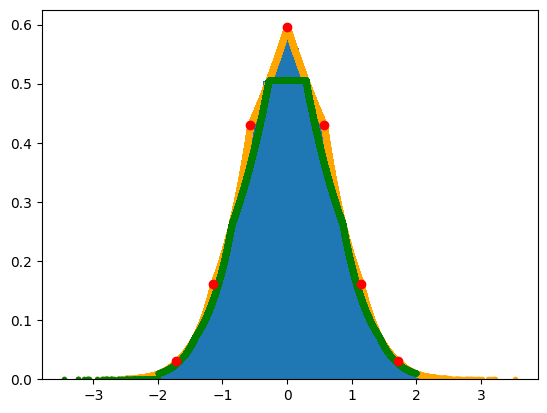

In [47]:
_ = plt.hist(samples2, bins=100, density=True)
_ = plt.scatter(samples2, jnp.exp(logpdf)/state.s[state.current_support_points], color='orange', marker=".")
_ = plt.scatter(samples2, jnp.exp(logpdf_lower)/state.s[state.current_support_points], color='green', marker=".")
_ = plt.scatter(state.z, jnp.exp(state.u)/state.s[state.current_support_points], color="red")